**Project 3 - Urban Heat in Zurich 1985-2024**

Question: How did LST and NDVI change from 1985 to 2024 and is there a possible correlation (visually)?


In [9]:
# install libraries
import rioxarray
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# load and inspect data
data_2024 = rioxarray.open_rasterio("../data/LandsatComposite_Zurich_2024.tif")
data_2024

<xarray.DataArray (band: 7, y: 252, x: 297)> Size: 4MB
[523908 values with dtype=float64]
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * y            (y) float64 2kB 5.253e+06 5.253e+06 ... 5.245e+06 5.245e+06
  * x            (x) float64 2kB 4.6e+05 4.6e+05 4.6e+05 ... 4.688e+05 4.689e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')

In [13]:
# create list of data to prepare for loop to extract mean values
files = [
    "../data/LandsatComposite_Zurich_1985.tif",
    "../data/LandsatComposite_Zurich_1988.tif",
    "../data/LandsatComposite_Zurich_1991.tif",
    "../data/LandsatComposite_Zurich_1994.tif",
    "../data/LandsatComposite_Zurich_1997.tif",
    "../data/LandsatComposite_Zurich_2000.tif",
    "../data/LandsatComposite_Zurich_2003.tif",
    "../data/LandsatComposite_Zurich_2006.tif",
    "../data/LandsatComposite_Zurich_2009.tif",
    "../data/LandsatComposite_Zurich_2012.tif",
    "../data/LandsatComposite_Zurich_2015.tif",
    "../data/LandsatComposite_Zurich_2018.tif",
    "../data/LandsatComposite_Zurich_2021.tif",
    "../data/LandsatComposite_Zurich_2024.tif"
]

years_list = [1985, 1988, 1991, 1994, 1997, 2000, 2003, 2006, 2009, 2012, 2015, 2018, 2021, 2024]

In [14]:
# for loop to extract overall mean values of each dataset
# create empty lists
years = []
mean_ndvi = []
mean_lst = []

# for-loop to select needed bands
for i in range(len(files)):
    data = rioxarray.open_rasterio(files[i])

    red = data.sel(band=3)
    nir = data.sel(band=4)
    lst = data.sel(band=7)

    #calculate ndvi
    ndvi = (nir - red) / (nir + red)

    years.append(years_list[i])
    mean_ndvi.append(float(ndvi.mean()))
    mean_lst.append(float(lst.mean()))

    

In [16]:
# crate DataFrame
df = pd.DataFrame({
    "year" : years,
    "mean_ndvi" : mean_ndvi,
    "mean_lst" : mean_lst})
df

,year,mean_ndvi,mean_lst
0,1985,0.533143,301.934973
1,1988,0.525846,300.331244
2,1991,0.529560,301.846384
3,1994,0.540872,303.755825
4,1997,0.551348,300.666913
5,2000,0.565572,305.030489
6,2003,0.534408,305.352501
7,2006,0.541808,306.923132
8,2009,0.561700,305.349611
9,2012,0.555824,306.148102


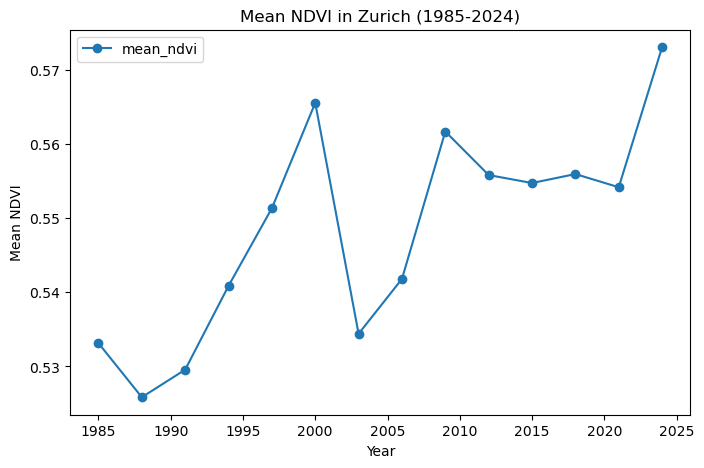

In [17]:
# visualize mean ndvi
df.plot(
    x="year",
    y="mean_ndvi",
    marker="o",
    figsize=(8,5)
)
plt.title("Mean NDVI in Zurich (1985-2024)")
plt.xlabel("Year")
plt.ylabel("Mean NDVI")
plt.show()

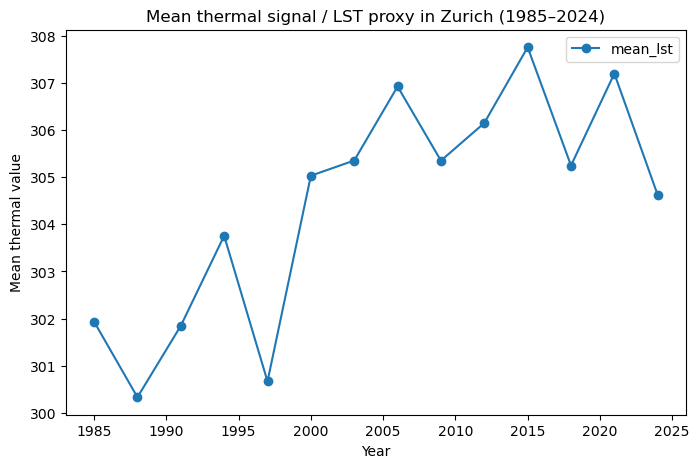

In [19]:
df.plot(
    x="year",
    y="mean_lst",
    marker="o",
    figsize=(8,5)
)
plt.title("Mean thermal signal / LST proxy in Zurich (1985–2024)")
plt.xlabel("Year")
plt.ylabel("Mean thermal value")
plt.show()

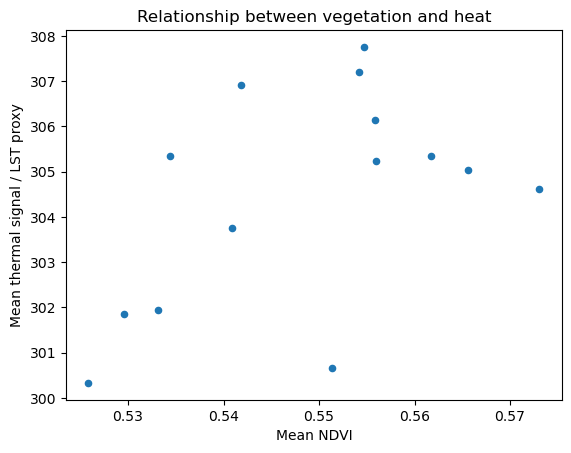

In [21]:
df.plot.scatter(
    x="mean_ndvi",
    y="mean_lst",
)

plt.title("Relationship between vegetation and heat")
plt.xlabel("Mean NDVI")
plt.ylabel("Mean thermal signal / LST proxy")
plt.show()

In [22]:
# visually compare first and last date
data_1985 = rioxarray.open_rasterio("../data/LandsatComposite_Zurich_1985.tif")
data_2024 = rioxarray.open_rasterio("../data/LandsatComposite_Zurich_2024.tif")

red_1985 = data_1985.sel(band=3)
nir_1985 = data_1985.sel(band=4)
lst_1985 = data_1985.sel(band=7)

red_2024 = data_2024.sel(band=3)
nir_2024 = data_2024.sel(band=4)
lst_2024 = data_2024.sel(band=7)

ndvi_1985 = (nir_1985 - red_1985) / (nir_1985 + red_1985)
ndvi_2024 = (nir_2024 - red_2024) / (nir_2024 + red_2024)

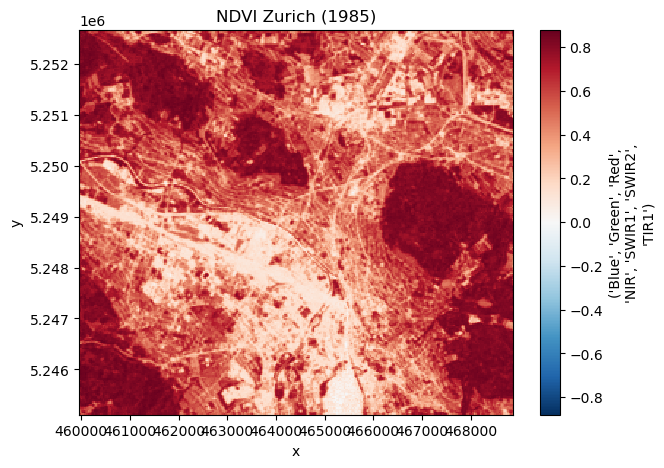

In [27]:
ndvi_1985.plot(figsize=(7, 5))

plt.title("NDVI Zurich (1985)")
plt.show()

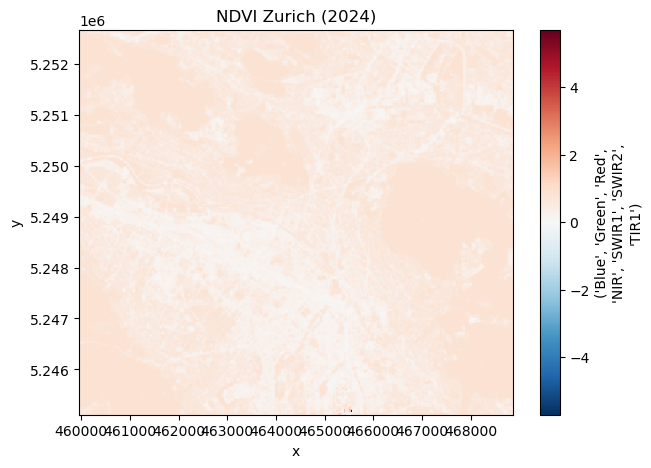

In [28]:
ndvi_2024.plot(figsize=(7, 5))

plt.title("NDVI Zurich (2024)")
plt.show()

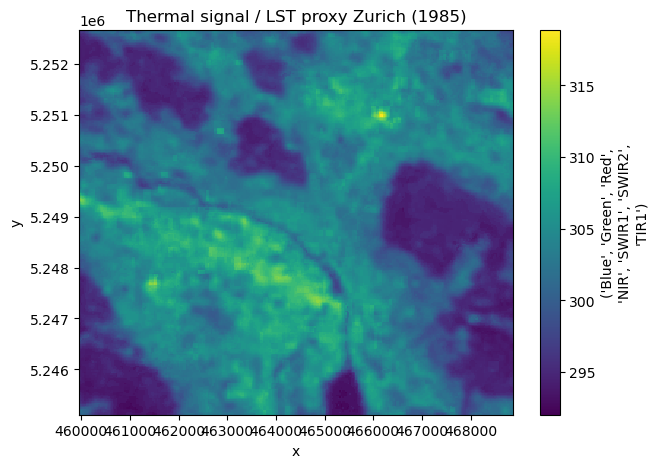

In [29]:
lst_1985.plot(figsize=(7, 5))

plt.title("Thermal signal / LST proxy Zurich (1985)")
plt.show()

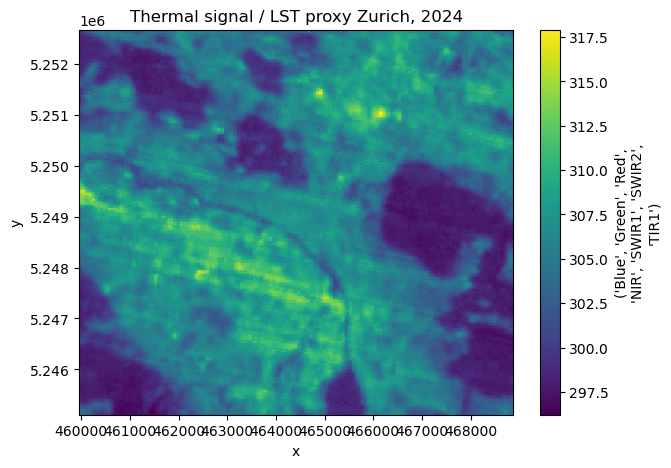

In [26]:
lst_2024.plot(figsize=(7, 5))

plt.title("Thermal signal / LST proxy Zurich, 2024")
plt.show()